# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file
# ====================================
data = pd.read_csv("problem1.csv")
data.describe()

,x0,x1,y
count,1306.000000,1306.000000,1306.000000
mean,-0.115656,-0.143498,0.173047
std,1.988625,1.975291,0.378433
min,-6.459190,-5.476284,0.000000
25%,-1.610326,-1.600044,0.000000
50%,-0.287934,-0.468113,0.000000
75%,1.516752,1.485145,0.000000
max,4.704646,4.952829,1.000000


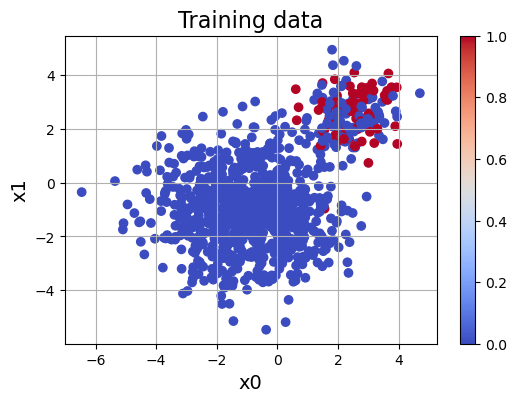

In [12]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
# ====================================
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']
# ====================================
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()

Best accuarcy: 0.9266666666666666
Best max_depth: 5
Best min_samples: 3
Confusion matrix: 
 [[130  20]
 [  2 148]]
Accuracy: 0.92


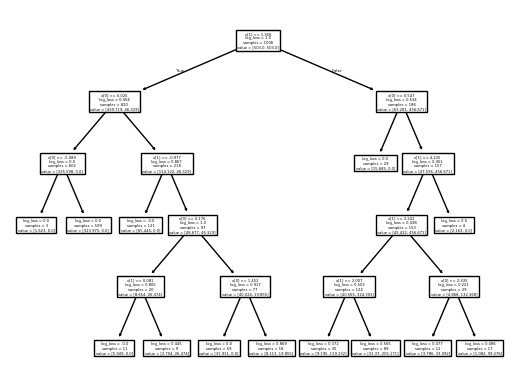

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ====================================
# YOUR CODE GOES HERE
# ====================================
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures, MinMaxScaler
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.tree import plot_tree

def make_features(data : pd.DataFrame)-> pd.DataFrame:
    # data = data.assign(x0_m_x1 = data['x0']*data['x1'])
    # data = data.assign(x0_p_x1 = data['x0']+data['x1'])
    # data = data.assign(x0_d_x1 = data['x0']/data['x1'])
    # data = data.assign(x0_2 = data['x0'].values**2)
    # data = data.assign(x1_2 = data['x1'].values**2)

    # data = data.assign(x_2_p = data['x0']**2 + data['x1']**2)
    # data = data.assign(dist = (data['x0']-np.mean(data['x0']))**2 + (data['x1']-np.mean(data['x1']))**2)
    # data = data.assign(x_min = np.minimum(data['x0'], data['x1']))
    # data = data.assign(x_max = np.maximum(data['x0'], data['x1']))
    # data = data.assign(relu = np.maximum(data['x0'], 0) * np.maximum(data['x1'], 0))

    # data = data.assign(angle = np.arctan2(data['x1'], data['x0']))
    # data = data.assign(cos = np.cos(data['angle']))
    # data = data.assign(sin = np.sin(data['angle']))
    # data = data.assign(dist = (data['x0']-3)**2 + (data['x1']-3)**2)
    # data = data.assign(x_2_m = data['x0_2'] * data['x1_2'])
    # data = data.assign(x_p_2 = (data['x0']+data['x1'])**2)
    return data

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

X_train = make_features(X_train)
X_test = make_features(X_test)

# scaler = RobustScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

accuracy, best_acc, best_d, best_s = 0,0,0,0
clf = DecisionTreeClassifier()
best_preds = 0
for d in range(1,20):
    for s in range(1,20):
        classifier = DecisionTreeClassifier(criterion='log_loss', max_depth=d, min_samples_leaf=s, class_weight='balanced')
        classifier.fit(X_train, y_train)
        preds = classifier.predict(X_test)
        accuracy = accuracy_score(y_test, preds)
        if accuracy > best_acc:
            best_acc = accuracy
            best_d = d
            best_s = s
            clf = classifier
            best_preds = preds
plot_tree(clf)

conf_matrix = confusion_matrix(y_test, best_preds)
print(f'Best accuarcy: {best_acc}')
print(f'Best max_depth: {best_d}')
print(f'Best min_samples: {best_s}')
print(f'Confusion matrix: \n {conf_matrix}')
# ====================================
print(f'Accuracy: {accuracy:.2f}')

Results:
No preprocessing, standard decisiontree(): 0.68
Standard scaler: 0.68
Criterion = 'log_loss': 0.71
Robust Scaler: 0.73
PolyFeatures(2), ingen skalering: 0.69

In [14]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
# ====================================
tpr = (conf_matrix[0][0] + conf_matrix[1][1]) / conf_matrix.sum()
fpr = (conf_matrix[0][1] + conf_matrix[1][0]) / conf_matrix.sum()
# ====================================
print(f"True positive rate: {tpr:.3f}")
print(f"False positive rate: {fpr:.3f}")

True positive rate: 0.937
False positive rate: 0.063


### ❓ What preprocessing do we need to apply before training, and why?

In theory not, the only adjustement needed was setting the 'class_weight'-attribute of the 'DecisionTreeClassifier', and the accuracy shot up to over 90%. What I did experiment with was feature engineering and hyperparameters of the model, specifically 'max_depth' and 'min_samples_leaf'. Using this strategy I only ever got 84% accuracy though.

### ❓ Do we need to scale the features?

Don't have to, and I tried it as well, with unsatisfactory results.

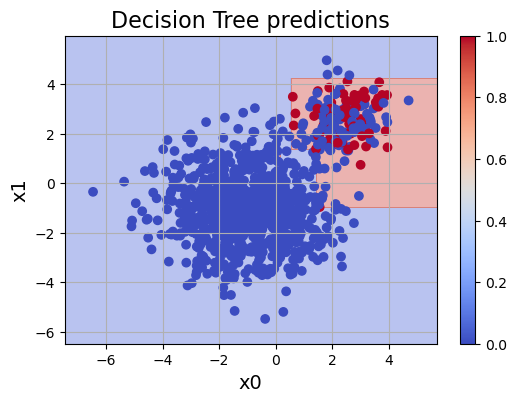

In [30]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = clf.predict(grid)
Z = Z.reshape(xx0.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train['x0'], X_train['x1'], c=y_train, cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Decision Tree predictions', fontsize=16)
plt.colorbar()
plt.show()

### ❓ What do you observe in the decision boundary plot before and after preprocessing?


### ❓ What happens when you increase or decrease the depth of the tree?


# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [152]:
df = pd.read_csv('problem2.csv')

Let's start by understanding the dataset.

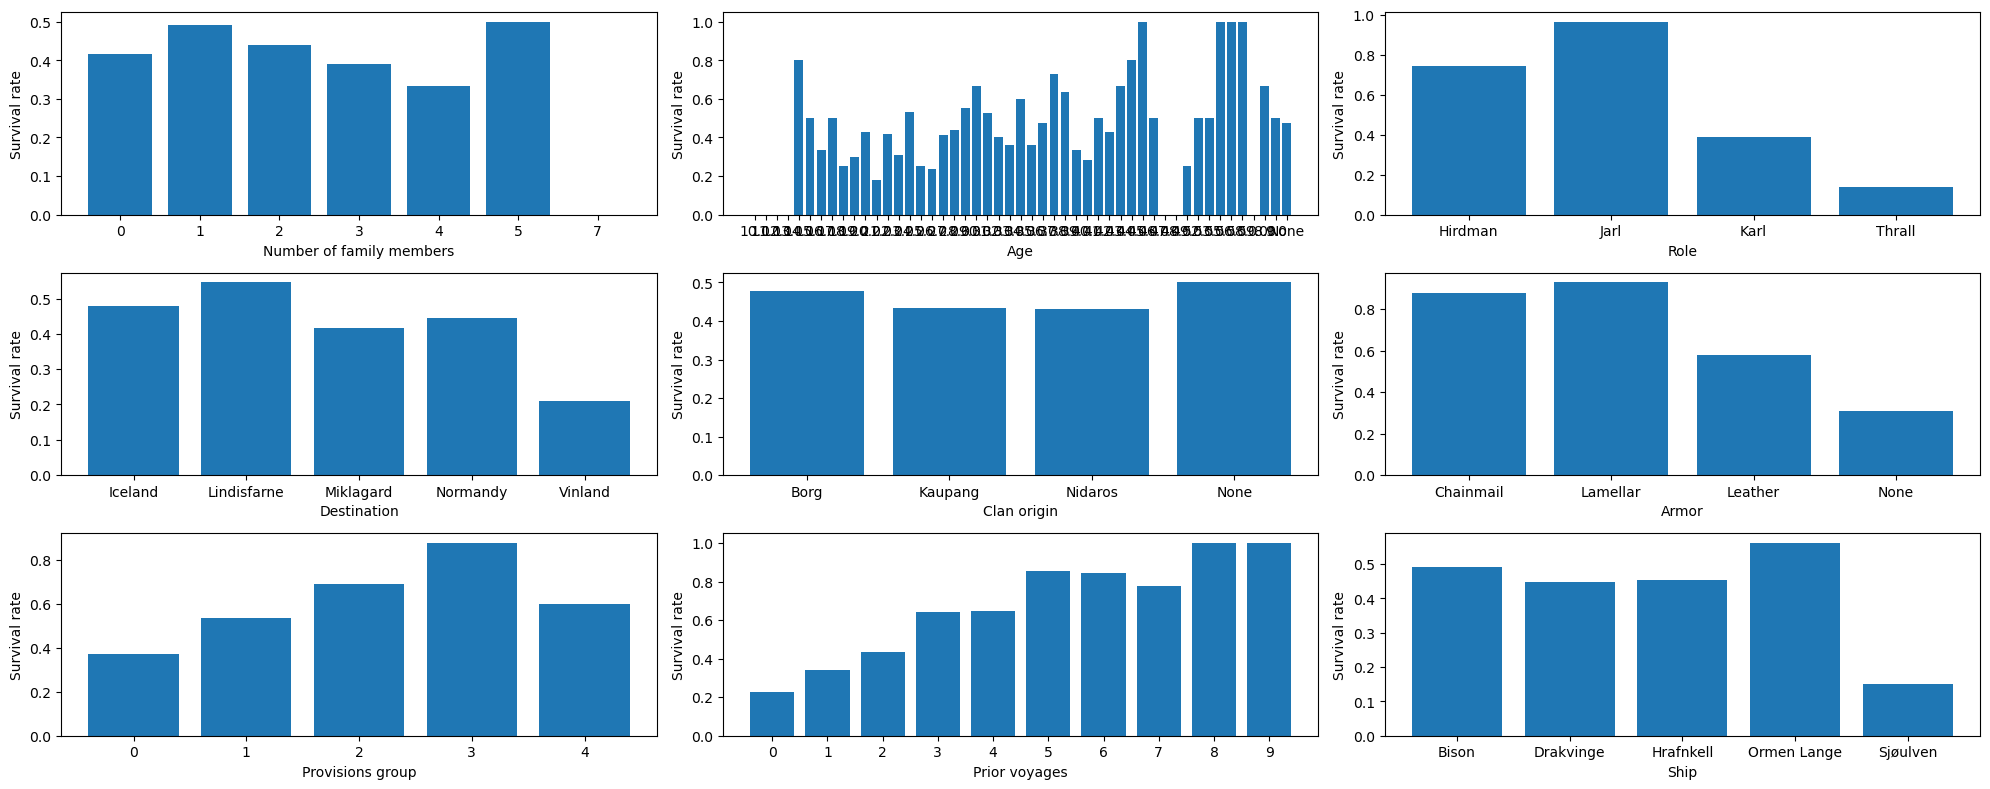

Female survival rate: 67.6%
Male survival rate: 35.7%


In [42]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================
rate_female = len(df[(df['sex'] == 'Female') & (df['survived'] == 1)]) / (len(df[(df['sex'] == 'Female') & (df['survived'] == 1)]) + len(df[(df['sex'] == 'Female') & (df['survived'] == 0)]))
rate_male = len(df[(df['sex'] == 'Male') & (df['survived'] == 1)]) / (len(df[(df['sex'] == 'Male') & (df['survived'] == 1)]) + len(df[(df['sex'] == 'Male') & (df['survived'] == 0)]))

# See what categories there are and their distribution:
# print(df.describe(include='all'))
rate_ship_1 = len(df[(df['ship'] == 'Bison') & (df['survived'] == 1)]) / (len(df[(df['ship'] == 'Bison') & (df['survived'] == 1)]) + len(df[(df['ship'] == 'Bison') & (df['survived'] == 0)]))
rate_ship_2 = len(df[(df['ship'] == 'Ormen Lange') & (df['survived'] == 1)]) / (len(df[(df['ship'] == 'Ormen Lange') & (df['survived'] == 1)]) + len(df[(df['ship'] == 'Ormen Lange') & (df['survived'] == 0)]))
rate_ship_3 = len(df[(df['ship'] == 'Sjøulven') & (df['survived'] == 1)]) / (len(df[(df['ship'] == 'Sjøulven') & (df['survived'] == 1)]) + len(df[(df['ship'] == 'Sjøulven') & (df['survived'] == 0)]))
rate_ship_4 = len(df[(df['ship'] == 'Hrafnkell') & (df['survived'] == 1)]) / (len(df[(df['ship'] == 'Hrafnkell') & (df['survived'] == 1)]) + len(df[(df['ship'] == 'Hrafnkell') & (df['survived'] == 0)]))
rate_ship_5 = len(df[(df['ship'] == 'Drakvinge') & (df['survived'] == 1)]) / (len(df[(df['ship'] == 'Drakvinge') & (df['survived'] == 1)]) + len(df[(df['ship'] == 'Drakvinge') & (df['survived'] == 0)]))
# print(rate_ship_1)
# print(rate_ship_2)
# print(rate_ship_3)
# print(rate_ship_4)
# print(rate_ship_5)
# Shows that ship 3 has much lower survival rate at 15%, where the others are around 44-56%

# Alternative preprocessing, not necessarily needed
# df['age_group'] = pd.cut(x = df['age'], bins=[0,10,20,30,40,50,60], labels=False)
# df['provisions_group'] = pd.cut(x = df['provisions_kg'], bins=[0,25,50,100,200,400], labels=False)

def check_survival_rate(target: str) -> dict:
    rates = {}
    for val in df[target].fillna('None').unique():
        group = df[df[target].fillna('None') == val]
        rates[str(val)] = group['survived'].mean()
    return rates

features = [
    ('family_aboard', 'Number of family members'),
    ('age', 'Age'),
    ('role', 'Role'),
    ('destination', 'Destination'),
    ('clan_origin', 'Clan origin'),
    ('armor', 'Armor'),
    ('provisions_group', 'Provisions group'),
    ('prior_voyages', 'Prior voyages'),
    ('ship', 'Ship')
]

fig, axes = plt.subplots(3, 3, figsize=(20, 8))

for ax, (col, label) in zip(axes.flatten(), features):
    rates = check_survival_rate(col)
    sorted_rates = dict(sorted(rates.items(), key=lambda x: x[0]))
    ax.bar(sorted_rates.keys(), sorted_rates.values())
    ax.set_xlabel(label)
    ax.set_ylabel('Survival rate')

fig.tight_layout()
plt.show()
# ====================================
print(f"Female survival rate: {rate_female:.1%}")
print(f"Male survival rate: {rate_male:.1%}")

### ❓ Are there any features that already predict survival better than a random guess?
Yes: the elders over 55 years, the crew with Jarl-roles, destination Lindisfarne, with armor, many prior voyages.

In [161]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================
# Make string-categories to "dummy-encoding", with 1 or 0 for what type of category
data = pd.read_csv('problem2.csv')
data['sex'] = (data['sex'] == 'Male').astype(int)
data = pd.get_dummies(
    data=data,
    columns=['role', 'ship', 'destination', 'clan_origin', 'armor'],
    dummy_na=True,
    dtype=int
)
data = data.drop(labels=['passenger_id','name'], axis=1) # Dropping irrelevant data

data = data.fillna(0.0)

X_train, X_test, y_train, y_test = train_test_split(data.drop(columns=['survived']), data['survived'], test_size=0.3, random_state=42)

clf = DecisionTreeClassifier()
best_a, best_d, best_s, best_cv_a = 0,0,0,0
best_cv = []

for d in range(1,25):
    for s in range(1,25):
        clf_t = DecisionTreeClassifier(
            criterion='gini',
            max_depth=d,
            min_samples_leaf=s,
            class_weight='balanced'
        )
        clf_t.fit(X_train, y_train)
        preds = clf_t.predict(X_test)
        a = accuracy_score(y_test, preds)
        cv_scores = cross_val_score(clf_t, X_train, y = y_train, cv=5)
        if cv_scores.mean() > best_cv_a:
            best_a = a
            best_d = d
            best_s = s
            best_cv_a = cv_scores.mean()
            clf = clf_t
            best_preds = preds
            best_cv = cv_scores

print(f'Best max_depth: {best_d}, best min_samples: {best_s}')
a = accuracy_score(y_test, best_preds)
cv_scores = best_cv
# ====================================
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")

True
False
Best max_depth: 4, best min_samples: 3
CV Accuracy: 0.771 ± 0.024
Test accuracy: 0.7800


### ❓ What is the purpose of cross validation?


In [132]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================
clf = DecisionTreeClassifier(criterion='gini', class_weight='balanced', max_depth=best_d, min_samples_leaf=best_s)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
a = accuracy_score(y_test, preds)
cv_scores = cross_val_score(clf, X_train, y = y_train)
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")

clf = DecisionTreeClassifier(criterion='log_loss', class_weight='balanced', max_depth=best_d, min_samples_leaf=best_s)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
a = accuracy_score(y_test, preds)
cv_scores = cross_val_score(clf, X_train, y = y_train)
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")


clf = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', max_depth=best_d, min_samples_leaf=best_s)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
a = accuracy_score(y_test, preds)
cv_scores = cross_val_score(clf, X_train, y = y_train)
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")

CV Accuracy: 0.726 ± 0.062
Test accuracy: 0.6933
CV Accuracy: 0.723 ± 0.058
Test accuracy: 0.6933
CV Accuracy: 0.723 ± 0.058
Test accuracy: 0.6933


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?
I do log_loss; it gets the second highest CV-mean score, while holding the lowest standard deviation.

[Text(0.5657894736842105, 0.9, 'x[31] <= 0.5\ngini = 0.5\nsamples = 350\nvalue = [175.0, 175.0]'),
 Text(0.34210526315789475, 0.7, 'x[16] <= 0.5\ngini = 0.403\nsamples = 120\nvalue = [35.533, 91.503]'),
 Text(0.45394736842105265, 0.8, 'True  '),
 Text(0.21052631578947367, 0.5, 'x[2] <= 21.6\ngini = 0.329\nsamples = 103\nvalue = [23.096, 88.072]'),
 Text(0.10526315789473684, 0.3, 'x[13] <= 0.5\ngini = 0.419\nsamples = 62\nvalue = [19.543, 45.752]'),
 Text(0.05263157894736842, 0.1, 'gini = 0.362\nsamples = 49\nvalue = [12.437, 40.033]'),
 Text(0.15789473684210525, 0.1, 'gini = 0.494\nsamples = 13\nvalue = [7.107, 5.719]'),
 Text(0.3157894736842105, 0.3, 'x[2] <= 59.9\ngini = 0.143\nsamples = 41\nvalue = [3.553, 42.32]'),
 Text(0.2631578947368421, 0.1, 'gini = 0.217\nsamples = 26\nvalue = [3.553, 25.163]'),
 Text(0.3684210526315789, 0.1, 'gini = 0.0\nsamples = 15\nvalue = [0.0, 17.157]'),
 Text(0.47368421052631576, 0.5, 'x[26] <= 0.5\ngini = 0.339\nsamples = 17\nvalue = [12.437, 3.431]'),

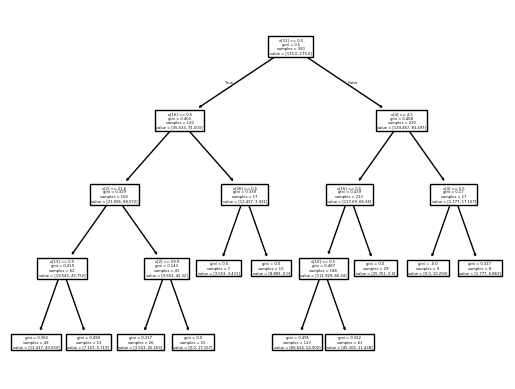

In [134]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
# ====================================
plot_tree(clf)

### ❓ What is Gini? Use an example from the decision tree graph you created.


## Improving the results with boosting 🚀

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================
best_cv = []
best_cv_a, best_d, best_est, best_lr = 0,0,0,0
clf_best = DecisionTreeClassifier()
ada_best = AdaBoostClassifier()
for depth in range(1,10):
    for estimator in [10,20,30,40,50]:
        for lr in [0.01, 0.05, 0.1, 0.5, 1, 5]:
            clf = DecisionTreeClassifier(criterion='gini', max_depth=depth)
            abc = AdaBoostClassifier(estimator=clf, random_state=42, learning_rate=lr, n_estimators=estimator)
            ada_cv_scores = cross_val_score(abc, X_train, y = y_train, cv = 5)
            if ada_cv_scores.mean() > best_cv_a:
                best_cv = ada_cv_scores
                best_cv_a = ada_cv_scores.mean()
                best_d = depth
                best_est = estimator
                clf_best = clf
                best_lr = lr
                ada_best = abc

print(f'Best hyperparameters: \n Depth: {best_d} \n Estimator: {best_est} \n Best learning rate: {best_lr}')


abc = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        criterion='gini',
        max_depth=best_d
    ),
    random_state=42,
    learning_rate=best_lr,
    n_estimators=best_est
)
ada_cv_scores = cross_val_score(abc, X_train, y_train, cv = 5)
abc.fit(X_train, y_train)
y_pred_ada = abc.predict(X_test)
# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

Best hyperparameters: 
 Depth: 4 
 Estimator: 30 
 Best learning rate: 0.1
AdaBoost CV Accuracy: 0.806 ± 0.011
AdaBoost test accuracy: 0.7533


### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

In [ ]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

In [ ]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================
